# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [1]:
!pip install nltk tqdm gensim gdown emoji evaluate

In [2]:
# standard library
import os
import sys
import time
import gc
import json
import shutil
import tarfile
import zipfile
import urllib
import codecs
import warnings
import random
import re
from pathlib import Path
from functools import reduce
from itertools import product
from collections import Counter, OrderedDict
from typing import List, Callable, Dict, Tuple

# data and numerical management packages
import numpy as np
import pandas as pd
import simplejson as sj
import copy
import scipy
from scipy import stats

# deep learning / ML
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import MultiStepLR
import tensorflow as tf  # remove if not used

# transformers / datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import evaluate

# sklearn metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# pre-processing
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag

# embeddings
import gensim
import gensim.downloader as gloader

# visualization
import matplotlib.pyplot as plt
import umap

# utility
import requests
import gdown
import emoji

# debugging / display
from tqdm import tqdm
from IPython.display import display

Download the dataset folder from Google Drive using gdown. The folder contains three JSON files: train, validation, and test

In [3]:
data_path = "https://drive.google.com/drive/folders/1l2mbz9ptBQcnHb1OK1D9OxFp3utxlx6v?usp=drive_link"

In [4]:
test_path, train_path, val_path = gdown.download_folder(data_path, quiet=False, use_cookies=False)

Retrieving folder contents


Processing file 1iHRg8UJ795as8iy398VFV_hDoPRE1njX test.json
Processing file 1RGmmJW3oE8o4_lu9DKunYNOFDvcgYEkz training.json
Processing file 1ihNtzeFVjvZRCRUvL4QY0l_89a2EltAG validation.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1iHRg8UJ795as8iy398VFV_hDoPRE1njX
To: /content/data/test.json
100%|██████████| 492k/492k [00:00<00:00, 5.28MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RGmmJW3oE8o4_lu9DKunYNOFDvcgYEkz
To: /content/data/training.json
100%|██████████| 6.22M/6.22M [00:00<00:00, 26.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ihNtzeFVjvZRCRUvL4QY0l_89a2EltAG
To: /content/data/validation.json
100%|██████████| 1.16M/1.16M [00:00<00:00, 11.9MB/s]
Download completed


Load each json file into a pandas DataFrame.

orient="index" tells pandas that the JSON keys are row indices

In [5]:
train_df = pd.read_json(train_path, orient="index")
val_df = pd.read_json(val_path, orient="index")
test_df = pd.read_json(test_path, orient="index")

In [6]:
print("Training dataset shape:", train_df.shape)
print("Validation dataset shape:", val_df.shape)
print("Test dataset shape:", test_df.shape)

Training dataset shape: (6920, 11)
Validation dataset shape: (726, 11)
Test dataset shape: (312, 11)


 Inspect the first training sample as a dictionary to verify that all expected fields are present and correctly loaded

In [7]:
train_df.iloc[0].to_dict()

{'id_EXIST': 100001,
 'lang': 'es',
 'tweet': '@TheChiflis Ignora al otro, es un capullo.El problema con este youtuber denuncia el acoso... cuando no afecta a la gente de izquierdas. Por ejemplo, en su video sobre el gamergate presenta como "normal" el acoso que reciben Fisher, Anita o Zöey cuando hubo hasta amenazas de bomba.',
 'number_annotators': 6,
 'annotators': ['Annotator_1',
  'Annotator_2',
  'Annotator_3',
  'Annotator_4',
  'Annotator_5',
  'Annotator_6'],
 'gender_annotators': ['F', 'F', 'F', 'M', 'M', 'M'],
 'age_annotators': ['18-22', '23-45', '46+', '46+', '23-45', '18-22'],
 'labels_task1': ['YES', 'YES', 'NO', 'YES', 'YES', 'YES'],
 'labels_task2': ['REPORTED',
  'JUDGEMENTAL',
  '-',
  'REPORTED',
  'JUDGEMENTAL',
  'REPORTED'],
 'labels_task3': [['OBJECTIFICATION'],
  ['OBJECTIFICATION', 'SEXUAL-VIOLENCE'],
  ['-'],
  ['STEREOTYPING-DOMINANCE'],
  ['SEXUAL-VIOLENCE'],
  ['IDEOLOGICAL-INEQUALITY', 'MISOGYNY-NON-SEXUAL-VIOLENCE']],
 'split': 'TRAIN_ES'}

In [8]:
train_df.columns

Index(['id_EXIST', 'lang', 'tweet', 'number_annotators', 'annotators',
       'gender_annotators', 'age_annotators', 'labels_task1', 'labels_task2',
       'labels_task3', 'split'],
      dtype='object')

To obtain a single ground-truth label for Task 2, we apply majority voting: the label chosen by the most annotators is selected.
If two or more labels are tied for the highest frequency, the sample is considered ambiguous and discarded (returns NaN)

In [9]:
def majority_vote(labels):
    #count frequencies
    counts = Counter(labels)
    #order lables from most to less frequent like [('DIRECT',2), ('REPORTED',2), ('JUDGEMENTAL',1)] and take just the first two
    most_common = counts.most_common(2)

    if len(most_common) == 0 or (len(most_common) > 1 and most_common[0][1] == most_common[1][1]):
        return np.nan

    else:
      return most_common[0][0]

Apply majority voting to the 'labels_task2' column for each split and store the result in a new 'label' column. Then remove rows where no majority coul be determined

In [10]:
train_df["label"] = train_df["labels_task2"].apply(majority_vote)
val_df["label"] = val_df["labels_task2"].apply(majority_vote)
test_df["label"] = test_df["labels_task2"].apply(majority_vote)

train_df = train_df.dropna(subset=["label"])
val_df = val_df.dropna(subset=["label"])
test_df = test_df.dropna(subset=["label"])

Verify the majority voting results by comparing 'label_task2' against 'label'

In [11]:
train_df[["labels_task2", "label"]].head()

,labels_task2,label
100001,"[REPORTED, JUDGEMENTAL, -, REPORTED, JUDGEMENT...",REPORTED
100002,"[-, -, -, -, DIRECT, -]",-
100003,"[-, -, -, -, -, -]",-
100004,"[-, -, DIRECT, -, REPORTED, REPORTED]",-
100006,"[-, -, -, -, -, -]",-


Check the class distribution of the training set after majority voting

In [12]:
train_df["label"].value_counts()

,count
label,
-,3987
DIRECT,1275
REPORTED,442
JUDGEMENTAL,360
UNKNOWN,1


The dataset is notably imbalanced: the non-sexist class ('-') accounts for roughly 65% of the training samples, while the three sexist categories together represent only ~34%. Among sexist tweets, 'DIRECT' is the most frequent, whereas 'REPORTED' and 'JUDGEMENTAL' are significantly underrepresented

Since we are working only with English tweets, we filter each split to retain only rows where lang == 'en'

In [13]:
train_df_en = train_df[train_df["lang"] == "en"]
val_df_en = val_df[val_df["lang"] == "en"]
test_df_en = test_df[test_df["lang"] == "en"]

In [14]:
print(f"Training data english shape: {train_df_en.shape}")
print(f"Validation data english shape: {val_df_en.shape}")
print(f"Test data english shape: {test_df_en.shape}")

Training data english shape: (2873, 12)
Validation data english shape: (150, 12)
Test data english shape: (280, 12)


Confirm that the filtered DataFrames contain only English tweets

In [15]:
train_df_en["lang"].value_counts()

,count
lang,
en,2873


Keep only the four columns relevant for the classification task

In [16]:
cols = ["id_EXIST", "lang", "tweet", "label"]

train_df_en = train_df_en[cols]
val_df_en = val_df_en[cols]
test_df_en = test_df_en[cols]

Verify that only the four expected columns remain

In [17]:
train_df_en.columns

Index(['id_EXIST', 'lang', 'tweet', 'label'], dtype='object')

Preview the first few rows of the cleaned training DataFrame

In [18]:
train_df_en.head()

,id_EXIST,lang,tweet,label
200001,200001,en,FFS! How about laying the blame on the bastard...,-
200002,200002,en,Writing a uni essay in my local pub with a cof...,REPORTED
200003,200003,en,@UniversalORL it is 2021 not 1921. I dont appr...,REPORTED
200004,200004,en,@GMB this is unacceptable. Use her title as yo...,-
200005,200005,en,‘Making yourself a harder target’ basically bo...,-


Map string labels to integer class indices for model compatibility

In [19]:
label_map = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}

Class distribution before encoding (shows raw string label counts)

In [20]:
train_df_en["label"].value_counts()

,count
label,
-,2014
DIRECT,537
REPORTED,184
JUDGEMENTAL,138


We can also observe that filtering for English-only tweets roughly halved the dataset size
 (from ~6065 to ~2873 samples), but the class imbalance worsened:
the non-sexist class now represents ~73% of the training data,
 up from ~65% before language filtering. The imbalance across sexist categories is also preserved,
with 'DIRECT' being nearly 4x more frequent than 'JUDGEMENTAL'.
This skew should be carefully accounted for during model training.

Apply the integer encoding to all three splits

In [21]:
train_df_en["label"] = train_df_en["label"].map(label_map)
val_df_en["label"] = val_df_en["label"].map(label_map)
test_df_en["label"] = test_df_en["label"].map(label_map)

Class distribution after encoding; confirms the mapping was applied correctly and the counts remain unchanged

In [22]:
train_df_en["label"].value_counts()

,count
label,
0,2014
1,537
3,184
2,138


Final preview of the fully preprocessed training DataFrame

In [23]:
train_df_en.head()

,id_EXIST,lang,tweet,label
200001,200001,en,FFS! How about laying the blame on the bastard...,0
200002,200002,en,Writing a uni essay in my local pub with a cof...,3
200003,200003,en,@UniversalORL it is 2021 not 1921. I dont appr...,3
200004,200004,en,@GMB this is unacceptable. Use her title as yo...,0
200005,200005,en,‘Making yourself a harder target’ basically bo...,0


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

Note: several preprocessing functions used here were introduced
during the laboratory sessions and reused directly in this notebook.

The following functions define the individual cleaning steps applied to each tweet:

In [24]:
def lower(text: str) -> str:
    """
    Transforms given text to lower case.
    """
    return text.lower()

def remove_emojis(text: str) -> str:
    """
    Removes all the emojis from the input text.

    :param text: the input text.

    :returns
        - the text without emojis.
    """
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=DeprecationWarning)
        return emoji.replace_emoji(codecs.decode(text, "unicode_escape"), "")

def remove_hashtags(text: str) -> str:
    """
    Removes all the hashtags from the input text.

    :param text: the input text.

    :returns
        - the text without the hashtags.
    """
    return re.sub(r"#\S+", "", text)

def remove_mentions(text: str) -> str:
    """
    Remove all user mentions (e.g., @user) from the text.

    :param text: input text
    :return: text without mentions
    """
    return re.sub(r"@\S+", "", text)

def remove_urls(text: str) -> str:
    """
    Remove all URLs from the text.

    :param text: input text
    :return: text without URLs
    """
    return re.sub(r'http\S+|www\S+', "", text)

def remove_special_characters(text: str) -> str:
    """
    Remove special characters (keep letters, numbers, and spaces).

    :param text: input text
    :return: cleaned text
    """
    return re.sub(r"[^A-Za-z0-9\s]", "", text)

def remove_quotes(text: str) -> str:
    """
    Remove quotation marks from the text.

    :param text: input text
    :return: text without quotes
    """
    return re.sub(r'[“”‘’]', "", text)

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing
    (including carriage return) from text.
    """
    return text.strip()

The pipeline defines the ordered sequence of cleaning functions to apply to each tweet

In [25]:
PREPROCESSING_PIPELINE = [
                          lower,
                          remove_emojis,
                          remove_hashtags,
                          remove_mentions,
                          remove_urls,
                          remove_special_characters,
                          remove_quotes,
                          strip_text
                          ]

def text_prepare(
    text: str,
    filter_methods: List[Callable[[str], str]] = None
) -> str:
    """
    Applies a list of pre-processing functions in sequence (reduce).
    Note that the order is important here!
    """
    filter_methods = filter_methods \
    if filter_methods is not None else PREPROCESSING_PIPELINE
    return reduce(lambda txt, f: f(txt), filter_methods, text)

Rename the 'tweet' column to 'original_tweet' to preserve the raw text

In [26]:
train_df_en = train_df_en.rename({"tweet": "original_tweet"}, axis="columns")
val_df_en = val_df_en.rename({"tweet": "original_tweet"}, axis="columns")
test_df_en = test_df_en.rename({"tweet": "original_tweet"}, axis="columns")

Preview the raw tweets before applying any cleaning

In [27]:
train_df_en.original_tweet.head()

,original_tweet
200001,FFS! How about laying the blame on the bastard...
200002,Writing a uni essay in my local pub with a cof...
200003,@UniversalORL it is 2021 not 1921. I dont appr...
200004,@GMB this is unacceptable. Use her title as yo...
200005,‘Making yourself a harder target’ basically bo...


Apply the preprocessing pipeline to all three splits. The cleaned text is stored in a new 'tweet' column

In [28]:
print('Pre-processing text...')
print()

# Replace each sentence with its pre-processed version
train_df_en['tweet'] = train_df_en['original_tweet'].apply(lambda txt: text_prepare(txt))
val_df_en['tweet'] = val_df_en['original_tweet'].apply(lambda txt: text_prepare(txt))
test_df_en['tweet'] = test_df_en['original_tweet'].apply(lambda txt: text_prepare(txt))

print("Pre-processing completed!")

Pre-processing text...

Pre-processing completed!


Preview the cleaned tweets to visually verify that the pipeline correctly removed emojis, hashtags, URLs, ecc...

In [29]:
train_df_en.tweet.head()

,tweet
200001,ffs how about laying the blame on the bastard ...
200002,writing a uni essay in my local pub with a cof...
200003,it is 2021 not 1921 i dont appreciate that on ...
200004,this is unacceptable use her title as you did ...
200005,making yourself a harder target basically boil...


**Lemmatization**

Lemmatization reduces each word to its canonical base form (example: *saw*, *seen*, *sees* $\rightarrow$ *see*) using WordNet

In [30]:
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()
tokenizer = WhitespaceTokenizer()

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Tokenizes the text using whitespace, assigns a POS tag to each token, then lemmatizes each token according to its POS tag.
The lemmatized tokens are finally joined back into a single string.

In [31]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

def lem_text(text: str):
    tokens = tokenizer.tokenize(text)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

Demonstrate the effect of lemmatization on the first training tweet. The output shows the cleaned tweet before and after lemmatization, making it easy to inspect which words were reduced to their base form.

In [32]:
example_text = train_df_en.iloc[0]["tweet"]

In [33]:
print(example_text)
print()
print(lem_text(example_text))

ffs how about laying the blame on the bastard who murdered her novel idea i know

ffs how about lay the blame on the bastard who murder her novel idea i know


Apply lemmatization to the 'tweet' column of all three splits

In [34]:
train_df_en["tweet"] = train_df_en["tweet"].apply(lem_text)
val_df_en["tweet"] = val_df_en["tweet"].apply(lem_text)
test_df_en["tweet"] = test_df_en["tweet"].apply(lem_text)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

### Vocabulary Creation
Since the text has been pre-processed, space splitting should work correctly. <br>

We proceed on building the vocabulary and perform some sanity checks.

The following function builds two lookup dictionaries from the training set:
- idx_to_word: maps integer indices to words
- word_to_idx: maps words to integer indices

**Note**: In this case, the vocabulary will start from index equal to 2, since two special tokens are added at fixed positions:
- `<PAD>` (index 0): used to pad sequences to equal length
- `<UNK>` (index 1): used to replace OOV tokens at inference time

In [35]:
def build_vocabulary(
    df: pd.DataFrame
) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Given a dataset, builds the corresponding word vocabulary.

    :param df: dataset from which we want to build
    the word vocabulary (pandas.DataFrame)
    :return:
      - word vocabulary: vocabulary index to word
      - inverse word vocabulary: word to vocabulary index
      - word listing: set of unique terms that build up the vocabulary
    """

    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()

    idx_to_word[0] = "<PAD>"
    word_to_idx["<PAD>"] = 0

    idx_to_word[1] = "<UNK>"
    word_to_idx["<UNK>"] = 1

    curr_idx = 2

    for sentence in tqdm(df.tweet.values):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1

    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

Build the vocabulary from the training set and inspect the first 10 entries

In [36]:
idx_to_word, word_to_idx, word_listing = build_vocabulary(train_df_en)
print(f'[Debug] Index -> Word vocabulary size: {len(idx_to_word)}')
print(f'[Debug] Word -> Index vocabulary size: {len(word_to_idx)}')

some_words = [(idx_to_word[idx], idx) for idx in range(10)]
print(f'[Debug] Some words: {some_words}')

100%|██████████| 2873/2873 [00:00<00:00, 56005.93it/s]

[Debug] Index -> Word vocabulary size: 9809
[Debug] Word -> Index vocabulary size: 9809
[Debug] Some words: [('<PAD>', 0), ('<UNK>', 1), ('ffs', 2), ('how', 3), ('about', 4), ('lay', 5), ('the', 6), ('blame', 7), ('on', 8), ('bastard', 9)]


### Vocabulary Evaluation

The following function runs a series of assertions to verify the correctness of the vocabulary:
- idx_to_word and word_to_idx are consistent with each other
- Building the vocabulary twice on the same data yields the
same result (determinism check)
- A toy example verifies that exactly the right tokens are
included (no duplicates, no missing words)


In [37]:
def evaluate_vocabulary(
    idx_to_word: Dict[int, str],
    word_to_idx: Dict[str, int],
    word_listing: List[str],
    df: pd.DataFrame,
    check_default_size: bool = False
):
    assert len(idx_to_word) == len(word_to_idx)
    assert len(idx_to_word) == len(word_listing)

    for i in tqdm(range(0, len(idx_to_word))):
        assert idx_to_word[i] in word_to_idx
        assert word_to_idx[idx_to_word[i]] == i

    _, _, first_word_listing = build_vocabulary(df)
    _, _, second_word_listing = build_vocabulary(df)
    assert first_word_listing == second_word_listing

    toy_df = pd.DataFrame.from_dict({
        'tweet': ["all that glitters is not gold",
                 "all in all i like this assignment"]
    })
    _, _, toy_word_listing = build_vocabulary(toy_df)
    toy_valid_vocabulary = set(' '.join(toy_df.tweet.values).split())
    toy_valid_vocabulary.update({"<PAD>", "<UNK>"})
    assert set(toy_word_listing) == toy_valid_vocabulary

In [38]:
print("Vocabulary evaluation...")
evaluate_vocabulary(idx_to_word, word_to_idx, word_listing, train_df_en)
print("Evaluation completed!")

Vocabulary evaluation...


100%|██████████| 2/2 [00:00<00:00, 24600.02it/s]

Evaluation completed!


Generally speaking, it is a good idea to save the dictionary in clear format.

$\rightarrow$ In this way you can quickly check for errors or useful words.

In this case, we will save the vocabulary dictionary in **JSON format**.

In [39]:
vocab_path = Path.cwd().joinpath('Datasets', "aclImdb", 'vocab.json')
vocab_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Saving vocabulary to {vocab_path}")
with vocab_path.open(mode='w') as f:
    sj.dump(word_to_idx, f, indent=4)
print("Saving completed!")

Saving vocabulary to /content/Datasets/aclImdb/vocab.json
Saving completed!


In [40]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")

    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

In [41]:
# Modify these variables as you wish!
# Glove -> 50, 100, 200, 300
embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=50)

In [42]:
print(len(embedding_model))
print(embedding_model.vectors.shape)

400000
(400000, 50)


### Handle OOV tokens
Identifies tokens present in our training vocabulary but missing
from GloVe. All the tokens in GloVe but not in the training set **must** be added to the vocabulary.

In [43]:
#Which words in my vocabulary are NOT in GloVe?
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing: List[str]):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

In [44]:
oov_terms = check_OOV_terms(embedding_model, word_listing)
oov_percentage = float(len(oov_terms)) * 100 / len(word_listing)
print(f"Total OOV terms: {len(oov_terms)} ({oov_percentage:.2f}%)")
print("OOV terms:", list(oov_terms)[:10])

Total OOV terms: 1835 (18.71%)
OOV terms: ['gimbap', 'riazs', 'undertale', 'muttersnonsense', 'wowsers', '27any', '16113rd', 'perfs', 'domadjacent', 'youlink']


Out of the tokens in our training vocabulary, 18.71%
 are not covered by GloVe. These OOV tokens are assigned a small random embedding, which allows the model to still process them while keeping their initial representations small and neutral.

The following function builds a matrix of shape (|V| x d) where each row corresponds to the embedding vector of a word in our vocabulary:
- `<PAD>`  -> zero vector (no contribution to computations)
- GloVe words -> pre-trained GloVe vector
- OOV words -> random vector sampled from Uniform(-0.05, 0.05)

In [45]:
def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str]) -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given
    a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector
        to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((len(word_to_idx), embedding_dimension), dtype=np.float32)
    word_to_emb = {}

    for word, idx in tqdm(word_to_idx.items()):
        try:
            if word == '<PAD>':
                embedding_vector = np.zeros_like((embedding_dimension))
            else:
                embedding_vector = embedding_model[word]
        except (KeyError, TypeError):
            embedding_vector =  np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector
        word_to_emb[word] = embedding_vector

    return embedding_matrix, word_to_emb

In [46]:
# Testing
embedding_dimension = 50
embedding_matrix, word_to_emb = build_embedding_matrix(embedding_model,
                                          embedding_dimension,
                                          word_to_idx,
                                          len(word_to_idx),
                                          oov_terms)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

100%|██████████| 9809/9809 [00:00<00:00, 92261.37it/s]

Embedding matrix shape: (9809, 50)


Visualize the first elements of the embedding matrix:

In [47]:
print(np.round(embedding_matrix[:3],4))

[[ 0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.      0.      0.      0.    ]
 [-0.0354  0.0401 -0.0153 -0.0311 -0.0208  0.0116 -0.0429 -0.0278 -0.009
   0.0256  0.0128 -0.0072  0.0497  0.0113  0.0296  0.0181  0.0261  0.0047
  -0.025   0.0025 -0.0269 -0.0359 -0.0343  0.0077 -0.0428 -0.0458 -0.0484
   0.0162 -0.0459 -0.0178 -0.0236  0.0243 -0.0441  0.0036 -0.0279  0.0451
   0.0019 -0.0143  0.0085 -0.0026  0.003   0.0414 -0.024  -0.0049 -0.0423
   0.0232  0.0358  0.0433 -0.0032  0.0175]
 [-0.1545 -0.6467  0.6734 -0.4333 -0.2038 -0.1745  1.0944 -0.4054 -0.846
  -1.0253  1.3264 -0.5401 -0.6078  0.4924 -1.0294  0.0291 -0.471   0.5466
   0.8652  0.1449 -1.5085 -0.5406 -0.4687  0.533

The next step is to visualize our sparse word embeddings in a lower dimensional space (2D) in order to have an idea of the meaning attributed to each word. To do this we will use UMAP which stands for **Uniform Manifold Approximation and Projection for Dimensionality Reduction**

In [48]:
def reduce_umap(embeddings: np.ndarray) -> np.ndarray:
    """
    Applies UMAP dimensionality reduction.
    """
    umap_emb = umap.UMAP(n_components=2, metric='cosine')
    reduced = umap_emb.fit_transform(embeddings)

    return reduced

In [49]:
reduced_embedding_umap = reduce_umap(embedding_matrix)

In [50]:
def visualize_embeddings(embeddings: np.ndarray,
                         word_annotations: List[str] = None,
                         word_to_idx: Dict[str, int] = None):
    """
    Plots given reduce word embeddings (2D). Users can highlight specific words (word_annotations list).

    :param embeddings: word embedding matrix of shape (words, 2) retrieved via a dimensionality reduction technique.
    :param word_annotations: list of words to be annotated.
    :param word_to_idx: vocabulary map (word -> index) (dict)
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    if word_annotations:
        print(f"Annotating words: {word_annotations}")

        word_indexes = []
        for word in word_annotations:
            word_index = word_to_idx[word]
            word_indexes.append(word_index)

        word_indexes = np.array(word_indexes)

        other_embeddings = embeddings[np.setdiff1d(np.arange(embeddings.shape[0]), word_indexes)]
        target_embeddings = embeddings[word_indexes]

        ax.scatter(other_embeddings[:, 0], other_embeddings[:, 1], alpha=0.1, c='blue')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1.0, c='red')
        ax.scatter(target_embeddings[:, 0], target_embeddings[:, 1], alpha=1, facecolors='none', edgecolors='r', s=1000)

        for word, word_index in zip(word_annotations, word_indexes):
            word_x, word_y = embeddings[word_index, 0], embeddings[word_index, 1]
            ax.annotate(word, xy=(word_x, word_y))
    else:
        ax.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.1, c='blue')

    # We avoid outliers ruining the visualization if they are quite far away
    axis_x_limit = (np.min(embeddings[:, 0]), np.max(embeddings[:, 0]))
    axis_y_limit = (np.min(embeddings[:, 1]), np.max(embeddings[:, 1]))
    plt.xlim(left=axis_x_limit[0] - 0.5, right=axis_x_limit[1] + 0.5)
    plt.ylim(bottom=axis_y_limit[0] - 0.5, top=axis_y_limit[1] + 0.5)
    ax.set_xlim(axis_x_limit[0], axis_x_limit[1])
    ax.set_ylim(axis_y_limit[0], axis_y_limit[1])

Plot the 2D UMAP projection of the embedding matrix.
Specific words ('good', 'love', 'beautiful') are highlighted in red to verify that semantically related words appear close together in the reduced space (this demonstrates that the embeddings capture meaningful semantic relationships)

Annotating words: ['good', 'love', 'beautiful']


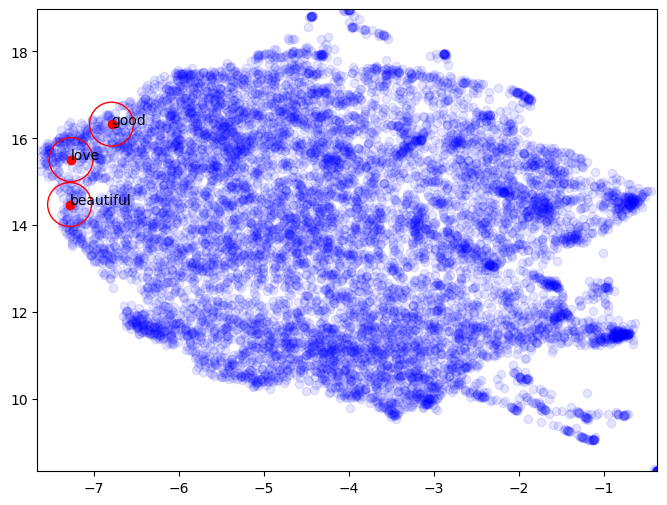

In [51]:
visualize_embeddings(reduced_embedding_umap,
                     ['good', 'love', 'beautiful'],
                     word_to_idx)

# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [52]:
# embedding = tf.keras.layers.Embedding(input_dim=vocab_size,
#                                       output_dim=embedding_dimension,
#                                       weights=[embedding_matrix],
#                                       mask_zero=True,                   # automatically masks padding tokens
#                                       name='encoder_embedding')

https://www.codegenes.net/blog/pytorch-blstm/

### BiLSTM Model
Implementation inspired by: https://www.codegenes.net/blog/pytorch-blstm/

The BiLSTMModel class implements both model variants depending
on the num_layers parameter passed at instantiation:

  - Baseline (num_layers=1): a single BiLSTM layer that processes the input sequence in both directions, followed by dropout
  and a fully connected layer that maps to the output classes.

  - Stacked (num_layers=2): two BiLSTM layers stacked on top of
  each other, where the output of the first layer is fed as
  input to the second. Dropout is applied between layers and
  before the final fully connected layer. This deeper architecture
  can capture more abstract sequential patterns at the cost of
  higher computational complexity.

In both variants, the Embedding layer is initialized with the
pre-trained GloVe matrix.
After the BiLSTM processes the full sequence, only the output at the last time step is extracted as the tweet representation, as it summarizes context from both the forward and backward passes.
This vector is then passed to the classification head.

In [53]:
class BiLSTMModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, num_layers, output_dim, dropout_prob, freeze_embedding=False):
        super(BiLSTMModel, self).__init__()

        if not isinstance(embedding_matrix, torch.Tensor):
            embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_matrix,
            freeze=freeze_embedding,
            padding_idx=0
        )

        # The LSTM input size is now determined by your embedding matrix's dimensions
        embedding_dim = embedding_matrix.shape[1]

        # batch_first=True makes standardizing input shapes much easier: (batch, seq_len, features)
        self.bilstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                              bidirectional=True, batch_first=True,
                              dropout= dropout_prob if num_layers > 1 else 0.0)

        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size * 2, output_dim)

    def forward(self, x):
        """
        x: Tensor of token ids of shape [batch_size, sequence_length]
        """
        # 1. Pass input token IDs through the embedding layer
        # Output shape: [batch_size, sequence_length, embedding_dim]
        embedded = self.embedding(x)

        # 2. Pass embeddings to BiLSTM
        # Note: PyTorch automatically initializes h0 and c0 to zeros if not provided!
        # This removes the need for your previous manual initialization.
        output, _ = self.bilstm(embedded)

        # 3. Get the last output of the sequence
        # Because we used batch_first=True, output shape is [batch_size, seq_len, hidden_size*2]
        # We grab all batches (:), the very last sequence step (-1), and all hidden features (:)
        last_output = output[:, -1, :]

        # 4. Dropout and Fully Connected
        last_output = self.dropout(last_output)
        logits = self.fc(last_output)

        return logits

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

### Data Preparation
Before training, we need to prepare the data for the model:
- Replace OOV tokens in validation and test sets with `<UNK>`
- Analyze sequence lengths to determine the padding length
- Encode tweets as sequences of token IDs
- Pad/truncate all sequences to a fixed length
- Wrap data into PyTorch `DataLoader` objects

Once the data is ready, both models are trained over multiple random seeds to obtain robust performance estimates. The best checkpoint per seed (highest validation macro F1) is saved and used for final evaluation.

#### OOV Handling
Tokens in the validation and test sets that are not present in
the training vocabulary are replaced with the special <UNK> token.
This is necessary because the embedding layer has no vector for
unseen tokens

In [54]:
def handle_unk(sentence: str, word_to_emb: Dict):
    """
    It handle the <UNK> tokens.
    :param sentence: the input sentence.
    :param word_to_emb: the word to embedding mapping.
    :returns:
        - the sentence with <UNK> tokens.
    """
    tokens = sentence.split()
    tweet = [token if token in word_to_emb.keys() else "<UNK>" for token in tokens]
    return ' '.join(tweet)

One example before and after
the substitution for verification:

In [55]:
print(val_df_en.tweet.iloc[0])
val_df_en.tweet =val_df_en.tweet.apply(lambda tweet: handle_unk(tweet, word_to_emb))
print(val_df_en.tweet.iloc[0])

you should smile more love just pretend youre a tory open a food bank be only live through the bad in live memory so it all a bit of a giggle cheer up darling it might never happen
you should smile more love just pretend youre a tory open a food <UNK> be only live through the bad in live memory so it all a bit of a <UNK> cheer up darling it might never happen


In [56]:
test_df_en.tweet = test_df_en.tweet.apply(lambda tweet: handle_unk(tweet, word_to_emb))

#### Sequence Length analysis
Before padding, we analyze the distribution of tweet lengths
(in tokens) across the training set. This guides the choice of
max_sequence_length: a value too small would truncate many tweets,
while a value too large would add unnecessary padding.
Percentile statistics (90th, 95th, 99th) help find a length that
covers the vast majority of sequences without wasteful padding

In [57]:
def analyze_sequence_lengths(df: pd.DataFrame, column_name='tweet'):
    """
    Analyze sequence lengths in dataset
    """
    print("\nAnalyzing sequence lengths...")

    # Calculate lengths by splitting each tweet
    lengths = [len(sentence.split()) for sentence in df[column_name].values]

    stats = {
        'min': int(np.min(lengths)),
        'max': int(np.max(lengths)),
        'mean': float(np.mean(lengths)),
        'median': float(np.median(lengths)),
        'std': float(np.std(lengths)),
        'percentile_90': int(np.percentile(lengths, 90)),
        'percentile_95': int(np.percentile(lengths, 95)),
        'percentile_99': int(np.percentile(lengths, 99)),
    }

    print("\nSequence Length Statistics:")
    print(f"  Min:    {stats['min']}")
    print(f"  Max:    {stats['max']}")
    print(f"  Mean:   {stats['mean']:.2f}")
    print(f"  Median: {stats['median']:.2f}")
    print(f"  Std:    {stats['std']:.2f}")
    print(f"  90th percentile: {stats['percentile_90']}")
    print(f"  95th percentile: {stats['percentile_95']}")
    print(f"  99th percentile: {stats['percentile_99']}")

    # Show coverage analysis
    print(f"\nCoverage analysis:")
    for percentile in [90, 95, 99]:
        max_len = int(np.percentile(lengths, percentile))
        coverage = (np.array(lengths) <= max_len).sum() / len(lengths) * 100
        print(f"  max_sequence_length={max_len:3d} covers {coverage:.1f}% of sequences")

    return lengths, stats

In [58]:
lengths, stats = analyze_sequence_lengths(train_df_en)


Analyzing sequence lengths...

Sequence Length Statistics:
  Min:    1
  Max:    62
  Mean:   25.77
  Median: 24.00
  Std:    13.93
  90th percentile: 46
  95th percentile: 49
  99th percentile: 54

Coverage analysis:
  max_sequence_length= 46 covers 90.7% of sequences
  max_sequence_length= 49 covers 95.2% of sequences
  max_sequence_length= 54 covers 99.2% of sequences


Based on this analysis, we set max_sequence_length=54,
which covers 99.2% of training sequences with minimal truncation.

In [59]:
max_sequence_length = 54

#### Text Encoding
`encode_texts` converts each tweet from a list of string tokens
to a list of integer IDs using word_to_idx. Unknown tokens (already replaced by <UNK> above) are mapped to index 1.

In [60]:
def encode_texts(texts, word_to_idx):
    """
    Converts raw texts to sequences of token IDs.
    Uses .split() to be consistent with build_vocabulary
    """
    sequences = []
    for text in texts:
        tokens = text.split()    # ← same as build_vocabulary
        ids = [word_to_idx.get(token, word_to_idx['<UNK>']) for token in tokens]
        sequences.append(ids)
    return sequences

`decode_texts` performs the inverse operation, converting a sequence
of IDs back to a human-readable string (useful for debugging)

In [61]:
def decode_texts(sequences, idx_to_word):
    """
    Converts sequences of token IDs back to raw texts.
    Inverse of encode_texts
    """
    texts = []

    for seq in sequences:
        tokens = []
        for idx in seq:
            word = idx_to_word.get(idx, '<UNK>')
            tokens.append(word)
        texts.append(' '.join(tokens))

    return texts

Verify the encoding on a sample tweet: the original text is printed
first, followed by the corresponding sequence of token IDs:

In [62]:
print(test_df_en.tweet.iloc[0])
print(encode_texts([test_df_en.tweet.iloc[0]], word_to_idx))

1st day at the pool on a beautiful sunday in ny too bad few dare to go in due to the frigid water temp we last 45 min and figure we prove our point
[[5303, 702, 159, 6, 9514, 8, 18, 2092, 1318, 21, 3007, 536, 508, 815, 2461, 38, 105, 21, 1016, 38, 6, 5143, 4963, 5223, 136, 1192, 192, 2434, 50, 900, 136, 563, 235, 615]]


#### Padding/Truncation
All sequences are padded with zeros (`<PAD>` index) on the right
 to reach max_sequence_length, or truncated if they exceed it

In [63]:
def adjust_sequence_length(sequences, max_length, pad_value=0):
    """
    Pads / truncates all sequences to the same fixed length
    """
    padded = np.zeros((len(sequences), max_length), dtype=np.int64)

    for i, seq in enumerate(sequences):
        # Truncate if too long
        truncated = seq[:max_length]
        # Fill in the token IDs (rest stays 0 = <PAD>)
        padded[i, :len(truncated)] = truncated

    return padded

Run a full encode -> pad -> decode cycle on a single training tweets
to verify that all three functions work correctly and consistently.
The decoded text should match the original, with the only difference
being trailing `<PAD>` tokens filling up to max_sequence_length if the length of the encoded sequence was < 54

In [64]:
print("Original tweet:\n", train_df_en.tweet.iloc[0])

text_to_idx = encode_texts([train_df_en.tweet.iloc[0]], word_to_idx)
print("\nEncoded text (word to index):")
print(text_to_idx)

print("\nLength of encoded sequence:")
print(len(text_to_idx[0]))

padded_text = adjust_sequence_length(text_to_idx, max_sequence_length)
print("\nPadded sequence:")
print(padded_text[0])

print("\nDecoded text (index to word):\n", decode_texts(padded_text, idx_to_word)[0])

Original tweet:
 ffs how about lay the blame on the bastard who murder her novel idea i know

Encoded text (word to index):
[[2, 3, 4, 5, 6, 7, 8, 6, 9, 10, 11, 12, 13, 14, 15, 16]]

Length of encoded sequence:
16

Padded sequence:
[ 2  3  4  5  6  7  8  6  9 10 11 12 13 14 15 16  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]

Decoded text (index to word):
 ffs how about lay the blame on the bastard who murder her novel idea i know <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


In [65]:
print("Original tweet:\n", val_df_en.tweet.iloc[0])

text_to_idx = encode_texts([val_df_en.tweet.iloc[0]], word_to_idx)
print("\nEncoded text (word to index):")
print(text_to_idx)

print("\nLength of encoded sequence:")
print(len(text_to_idx[0]))

padded_text = adjust_sequence_length(text_to_idx, max_sequence_length)
print("\nPadded sequence:")
print(padded_text[0])

print("\nDecoded text (index to word):\n", decode_texts(padded_text, idx_to_word)[0])

Original tweet:
 you should smile more love just pretend youre a tory open a food <UNK> be only live through the bad in live memory so it all a bit of a <UNK> cheer up darling it might never happen

Encoded text (word to index):
[[78, 791, 219, 398, 399, 46, 375, 551, 18, 3936, 1001, 18, 3499, 1, 55, 119, 168, 337, 6, 508, 21, 168, 4248, 118, 53, 81, 18, 1947, 103, 18, 1, 2610, 47, 1567, 53, 408, 1168, 813]]

Length of encoded sequence:
38

Padded sequence:
[  78  791  219  398  399   46  375  551   18 3936 1001   18 3499    1
   55  119  168  337    6  508   21  168 4248  118   53   81   18 1947
  103   18    1 2610   47 1567   53  408 1168  813    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]

Decoded text (index to word):
 you should smile more love just pretend youre a tory open a food <UNK> be only live through the bad in live memory so it all a bit of a <UNK> cheer up darling it might never happen <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <P

#### DataLoaders
The following function encodes and pads all three splits, converts them to PyTorch tensors, and wraps them in DataLoader objects for efficient batched training.
 The training loader shuffles samples each epoch to improve
 generalization; validation and test loaders are not shuffled.

In [66]:
def create_dataloaders(df_train, df_val, df_test,
                       word_to_idx, max_length,
                       batch_size=64,
                       text_col='tweet', label_col='label'):
    """
    Takes DataFrames → encodes → pads → returns DataLoaders.
    """

    train_sequences = encode_texts(train_df_en[text_col].tolist(), word_to_idx)
    val_sequences = encode_texts(val_df_en[text_col].tolist(), word_to_idx)
    test_sequences = encode_texts(test_df_en[text_col].tolist(), word_to_idx)

    X_train = adjust_sequence_length(train_sequences, max_sequence_length)
    X_val = adjust_sequence_length(val_sequences, max_sequence_length)
    X_test = adjust_sequence_length(test_sequences, max_sequence_length)

    y_train = df_train[label_col].values
    y_val = df_val[label_col].values
    y_test = df_test[label_col].values

    X_train = torch.tensor(X_train, dtype=torch.long)
    X_val = torch.tensor(X_val,   dtype=torch.long)
    X_test = torch.tensor(X_test,  dtype=torch.long)

    y_train = torch.tensor(y_train, dtype=torch.long)
    y_val = torch.tensor(y_val,   dtype=torch.long)
    y_test = torch.tensor(y_test,  dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val),
                              batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test, y_test),
                              batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [67]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_df_en, val_df_en, test_df_en,
    word_to_idx=word_to_idx,
    max_length=max_sequence_length,
    batch_size=64,
    text_col='tweet',
    label_col='label'
)

### Training Configuration
All hyperparameters and paths are centralized in the Config class
to make experiments easy to reproduce and modify.
Key choices:
- HIDDEN_SIZE=128: controls the capacity of the BiLSTM
- DROPOUT_PROB=0.5: strong regularization given the small dataset
- NUM_EPOCHS=100
- SEEDS=[7, 42, 115]: three seeds for robust mean/std estimation
- FREEZE_EMBEDDINGS=False: GloVe vectors are fine-tuned during training

In [68]:
class Config:
    """Training configuration"""

    # Data parameters
    MAX_SEQUENCE_LENGTH = max_sequence_length
    PADDING_IDX = 0
    UNK_TOKEN = '<UNK>'

    # Model parameters
    EMBEDDING_DIM = 300
    HIDDEN_SIZE = 128
    NUM_LAYERS_BASELINE = 1  # Single BiLSTM layer
    NUM_LAYERS_STACKED = 2  # Two BiLSTM layers (stacked)

    DROPOUT_PROB = 0.5
    NUM_CLASSES = train_df_en.label.nunique()
    FREEZE_EMBEDDINGS = False

    # Training parameters
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 100

    SEEDS = [7, 42, 115]

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Paths
    SAVE_DIR = 'models'
    RESULTS_DIR = 'results'

    def __init__(self):
        """Create directories if they don't exist"""
        os.makedirs(self.SAVE_DIR, exist_ok=True)
        os.makedirs(self.RESULTS_DIR, exist_ok=True)

In [69]:
config = Config()
print(f"Configuration:")
print(f"  Device: {config.DEVICE}")
print(f"  Seeds: {config.SEEDS}")
print(f"  Batch size: {config.BATCH_SIZE}")
print(f"  Learning rate: {config.LEARNING_RATE}")
print(f"  Max epochs: {config.NUM_EPOCHS}")
print(f"  Embedding matrix shape: {embedding_matrix.shape}")

Configuration:
  Device: cuda
  Seeds: [7, 42, 115]
  Batch size: 32
  Learning rate: 0.001
  Max epochs: 100
  Embedding matrix shape: (9809, 50)


In [70]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

### Training and Evaluation
With the data prepared, we define the training configuration, compute class weights to handle label imbalance, and train both the Baseline and Stacked models over three random seeds. Results are reported as mean ± std of macro F1, precision, and recall on both validation and test sets

#### Handling class imbalance
Given the significant class imbalance observed in Task 1, we compute per-class weights using sklearn's 'balanced' strategy, which sets each weight inversely proportional to the class frequency.
This penalizes the loss function more heavily for underrepresented
classes (JUDGEMENTAL, REPORTED), encouraging the model to not simply
predict the dominant non-sexist class:

In [71]:
def compute_weights(labels):
  classes = np.unique(labels)
  counts = np.bincount(labels)
  n_samples = len(labels)
  n_classes = len(counts)

  weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)

  for i, cls in enumerate(classes):
    print(f"Class {cls}: {counts[i]} samples ({100*counts[i]/n_samples:.1f}%) -> weight: {weights[i]:.4f}")

  return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_weights(train_df_en["label"].values)
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(config.DEVICE)
)

Class 0: 2014 samples (70.1%) -> weight: 0.3566
Class 1: 537 samples (18.7%) -> weight: 1.3375
Class 2: 138 samples (4.8%) -> weight: 5.2047
Class 3: 184 samples (6.4%) -> weight: 3.9035


#### Training Loop
The following functions implement the full training pipeline:

- `train_epoch` runs one full pass over the training set, computing
the forward pass, loss, and backpropagation for each batch.

- `evaluate_model` runs inference over a dataloader with gradients
disabled, collecting predictions and computing loss, accuracy,
and macro F1/precision/recall.

- `train_model` orchestrates the full training loop over num_epochs,
tracking validation F1 at each epoch and saving the best model
state (highest validation F1) for later evaluation.

- `train_multiple_seeds` trains, for each seed, a new model instance from scratch and the
best checkpoint (highest validation F1) is reloaded before final evaluation on both validation and test sets. Training over multiple seeds gives a more reliable estimate of model performance, accounting
for the variance introduced by random weight initialization

In [72]:
def ncorrect(scores, y_pred):
  y_hat = torch.argmax(scores, -1)
  return (y_hat == y_pred).sum().item()

In [73]:
def compute_metrics(y_true: np.ndarray,
                   y_pred: np.ndarray,
                   average: str = 'macro') -> Dict[str, float]:
    return {
        'f1': float(f1_score(y_true, y_pred, average=average)),
        'precision': float(precision_score(y_true, y_pred, average=average, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, average=average, zero_division=0))
    }

def evaluate_model(model: nn.Module,
                  dataloader: DataLoader,
                  criterion: nn.Module,
                  device: torch.device) -> Dict:
    model.eval()
    val_loss = 0
    val_samples = 0
    val_acc = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            sequences, labels = batch
            sequences = sequences.to(device)
            labels = labels.to(device)

            # Forward pass
            val_scores = model(sequences)
            loss = criterion(val_scores, labels)

            # Get predictions
            _, predictions = torch.max(val_scores, 1)

            # Store results
            val_loss += loss.item() * sequences.size(0)
            val_samples += sequences.size(0)
            val_acc += ncorrect(val_scores, labels)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    # Compute metrics
    val_acc /= val_samples
    avg_loss = val_loss / val_samples
    metrics = compute_metrics(all_labels, all_predictions, average='macro')

    return {
        'loss': avg_loss,
        'predictions': all_predictions,
        'labels': all_labels,
        'accuracy': val_acc,
        **metrics
    }

In [74]:
def train_epoch(model: nn.Module,
               train_loader: DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               grad_clip: float = None,
               verbose: bool = True) -> float:
    model.train()
    train_loss = 0
    train_samples = 0
    train_acc = 0

    for batch in train_loader:
        sequences, labels = batch
        sequences = sequences.to(device)
        labels = labels.to(device)

        # Forward pass
        scores = model(sequences)
        loss = criterion(scores, labels)
        train_loss += loss.item() * sequences.size(0)
        train_samples += sequences.size(0)
        train_acc += ncorrect(scores, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_acc /= train_samples
    avg_loss = train_loss / train_samples

    return avg_loss

In [75]:
def train_model(model: nn.Module,
               train_loader: DataLoader,
               val_loader: DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               num_epochs: int,
               device: torch.device,
               model_name: str = 'model',
               save_path: str = None,
               verbose = False) -> Dict:
    """
    Complete training loop
    """
    history = {
        'train_loss': [],
        'val_acc': [],
        'val_loss': [],
        'val_f1': [],
        'val_precision': [],
        'val_recall': []
    }

    best_val_f1 = 0
    epochs_without_improvement = 0
    best_model_state = None

    if verbose:
        print(f"\n{'='*80}")
        print(f"Training {model_name}")
        print(f"{'='*80}")

    for epoch in range(num_epochs):

        # Train
        train_loss = train_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            verbose=verbose
        )

        # Evaluate on validation set
        val_results = evaluate_model(model, val_loader, criterion, device)

        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_results['loss'])
        history['val_acc'].append(val_results['accuracy'])
        history['val_f1'].append(val_results['f1'])
        history['val_precision'].append(val_results['precision'])
        history['val_recall'].append(val_results['recall'])

        if val_results['f1'] > best_val_f1:
            best_val_f1 = val_results['f1']
            best_model_state = model.state_dict().copy()

        # Print progress
        if verbose:
            print(f"\nEpoch {epoch+1}/{num_epochs}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        if save_path:
            torch.save(best_model_state, save_path)

    return {
        'history': history,
        'best_model_state': best_model_state
    }

In [76]:
def train_multiple_seeds(model_params: Dict,
                        train_loader: DataLoader,
                        val_loader: DataLoader,
                        test_loader: DataLoader,
                        config: Config,
                        criterion,
                        model_name: str = 'model') -> Dict:
    """
    Train model with multiple seeds for robust evaluation
    """
    results = {
        'seeds': config.SEEDS,
        'val_metrics': [],
        'test_metrics': [],
        'histories': [],
        'models': []
    }

    for seed in config.SEEDS:
        # Set seed for reproducibility
        fix_random(seed)

        # Create model
        model = BiLSTMModel(**model_params).to(config.DEVICE)

        # Loss and optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

        # Define save path for this seed's model
        model_save_dir = Path(config.SAVE_DIR) / model_name
        model_save_dir.mkdir(parents=True, exist_ok=True)
        current_save_path = model_save_dir / f"{model_name}_seed_{seed}.pt"

        # Train
        training_results = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=config.NUM_EPOCHS,
            device=config.DEVICE,
            model_name=f"{model_name}_seed{seed}",
            save_path=current_save_path
        )

        model.load_state_dict(training_results['best_model_state'])
        history = training_results['history']

        val_results = evaluate_model(model, val_loader, criterion, config.DEVICE)

        test_results = evaluate_model(model, test_loader, criterion, config.DEVICE)

        # Store results
        results['val_metrics'].append({
            'f1': val_results['f1'],
            'precision': val_results['precision'],
            'recall': val_results['recall'],
            'loss': val_results['loss'],
            'predictions': val_results['predictions'],
            'labels': val_results['labels'],
            'history': history
        })

        results['test_metrics'].append({
            'f1': test_results['f1'],
            'precision': test_results['precision'],
            'recall': test_results['recall'],
            'loss': test_results['loss'],
            'predictions': test_results['predictions'],
            'labels': test_results['labels'],
            'history': history
        })

        results['histories'].append(history)
        results['models'].append(training_results['best_model_state'])

        # Print summary
        print(f"\nSEED {seed}")
        print(f"Validation - F1: {val_results['f1']:.4f}, Prec: {val_results['precision']:.4f}, Rec: {val_results['recall']:.4f}")
        print(f"Test       - F1: {test_results['f1']:.4f}, Prec: {test_results['precision']:.4f}, Rec: {test_results['recall']:.4f}")

    return results

Define the parameter dictionaries for the two model variants.
The only difference between them is num_layers:

In [77]:
baseline_model_params = {
    'embedding_matrix': embedding_matrix,
    'hidden_size': config.HIDDEN_SIZE,
    'num_layers': config.NUM_LAYERS_BASELINE,
    'output_dim': config.NUM_CLASSES,
    'dropout_prob': config.DROPOUT_PROB,
    'freeze_embedding': config.FREEZE_EMBEDDINGS
}

stacked_model_params = {
    'embedding_matrix': embedding_matrix,
    'hidden_size': config.HIDDEN_SIZE,
    'num_layers': config.NUM_LAYERS_STACKED,
    'output_dim': config.NUM_CLASSES,
    'dropout_prob': config.DROPOUT_PROB,
    'freeze_embedding': config.FREEZE_EMBEDDINGS
}

In [78]:
print("TRAINING BASELINE MODEL (1 BiLSTM layer)")

baseline_results = train_multiple_seeds(
    model_params = baseline_model_params,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    config=config,
    criterion = criterion,
    model_name='Baseline'
)

TRAINING BASELINE MODEL (1 BiLSTM layer)

SEED 7
Validation - F1: 0.3644, Prec: 0.3991, Rec: 0.3448
Test       - F1: 0.3649, Prec: 0.4130, Rec: 0.3704

SEED 42
Validation - F1: 0.3228, Prec: 0.3750, Rec: 0.3589
Test       - F1: 0.3459, Prec: 0.3638, Rec: 0.3723

SEED 115
Validation - F1: 0.3825, Prec: 0.4834, Rec: 0.3888
Test       - F1: 0.3416, Prec: 0.3792, Rec: 0.3583


In [79]:
print("TRAINING STACKED MODEL (2 BiLSTM layer)")

stacked_results = train_multiple_seeds(
    model_params = stacked_model_params,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    config=config,
    criterion = criterion,
    model_name='Stacked'
)

TRAINING STACKED MODEL (2 BiLSTM layer)

SEED 7
Validation - F1: 0.3830, Prec: 0.4489, Rec: 0.3931
Test       - F1: 0.3550, Prec: 0.4003, Rec: 0.3581

SEED 42
Validation - F1: 0.4210, Prec: 0.5587, Rec: 0.4010
Test       - F1: 0.4056, Prec: 0.4336, Rec: 0.4089

SEED 115
Validation - F1: 0.3575, Prec: 0.3939, Rec: 0.3428
Test       - F1: 0.3243, Prec: 0.3583, Rec: 0.3450


#### Results and Analysis

The following function plot training/validation loss and validation F1 over epochs for each seed. This helps diagnose overfitting and assess training stability across seeds

In [80]:
def plot_training_curves(results: Dict, title: str):
    """Plot training curves"""

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    for i, history in enumerate(results['histories']):
        seed = results['seeds'][i]
        axes[0].plot(history['train_loss'], alpha=0.6, label=f'Train (seed {seed})')
        axes[0].plot(history['val_loss'], alpha=0.6, linestyle='--', label=f'Val (seed {seed})')
    axes[0].set_title(title + ' - Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # F1
    for i, history in enumerate(results['histories']):
        seed = results['seeds'][i]
        axes[1].plot(history['val_f1'], alpha=0.6, label=f'Seed {seed}')
    axes[1].set_title(title + ' - Validation F1', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

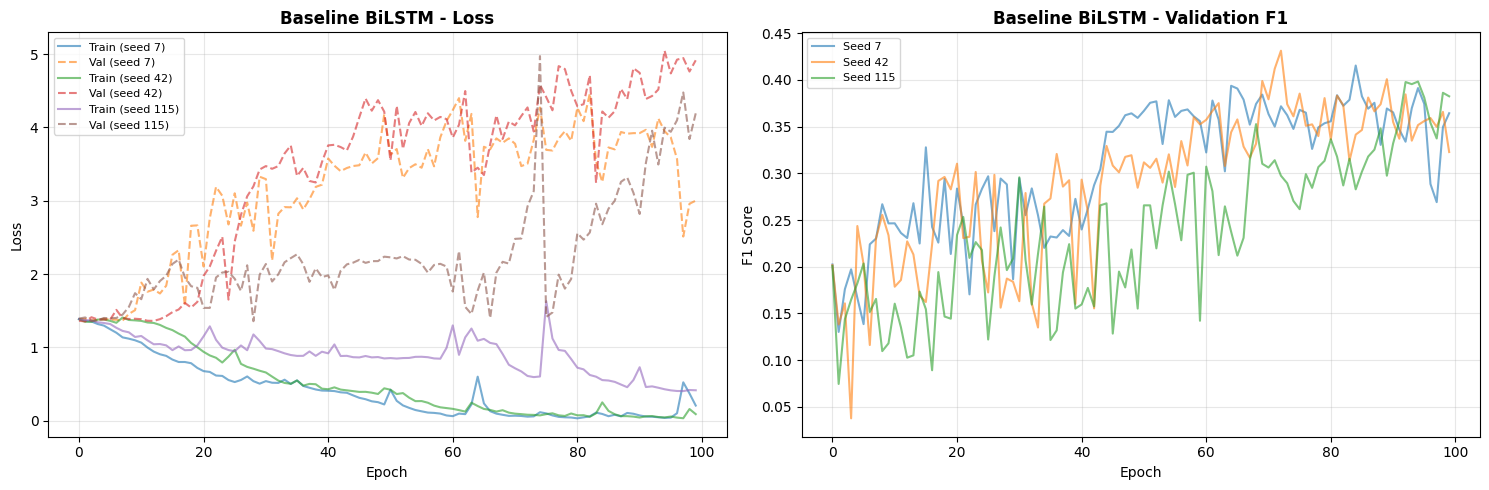

In [81]:
plot_training_curves(baseline_results, title = "Baseline BiLSTM")

The loss plots show a clear divergence between training and
validation across all seeds: while the training loss decreases
steadily, the validation loss grows continuously. However, this should not be interpreted as pure overfitting since the best model is selected based on validation F1 rather than loss, and so the validation loss is not directly controlled and is expected to diverge.
Looking at the F1 plot, despite the high oscillations, there is a clear upward trend across all seeds, suggesting that the model is steadily improving its ability to classify tweets correctly over time. All three seeds converge to
a similar range (~0.30-0.40) in the later epochs

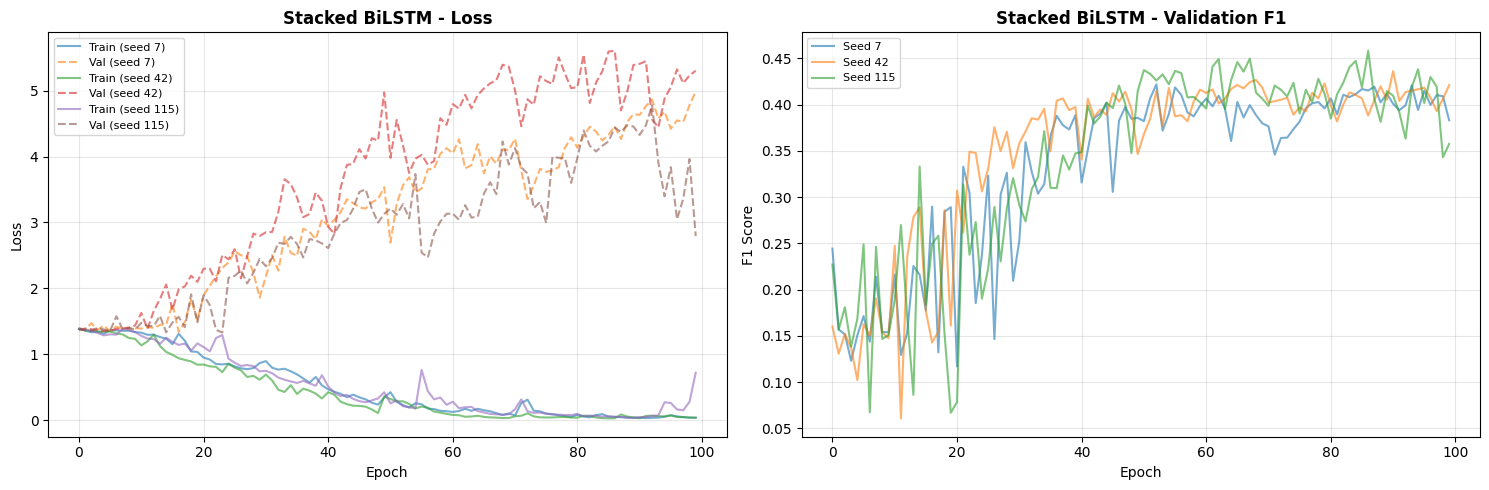

In [82]:
plot_training_curves(stacked_results, title = "Stacked BiLSTM")

Similarly to the baseline, the loss divergence between training
and validation is partly explained by the fact that the best model
is selected based on validation F1 rather than loss. The training
loss drops close to zero for all seeds, which combined with the
higher model capacity (two BiLSTM layers) does suggest some degree
of overfitting. Despite the oscillations, the validation F1 shows a clear upward trend across all seeds, with the model reaching a slightly higher and
more stable range (~0.35-0.45) compared to the baseline. This
suggests that the additional BiLSTM layer does capture more useful
representations, at the cost of a higher risk of overfitting.

The following function instead aggregate macro F1, precision, and recall across seeds for both splits, reporting mean ± std. This gives a reliable estimate of model performance and its variance across different initializations.

In [83]:
def compute_statistics(results: Dict) -> Dict:
    """Compute mean and std of metrics across seeds"""
    val_metrics = results['val_metrics']
    test_metrics = results['test_metrics']

    stats = {
        'validation': {
            'f1_mean': np.mean([m['f1'] for m in val_metrics]),
            'f1_std': np.std([m['f1'] for m in val_metrics]),
            'precision_mean': np.mean([m['precision'] for m in val_metrics]),
            'precision_std': np.std([m['precision'] for m in val_metrics]),
            'recall_mean': np.mean([m['recall'] for m in val_metrics]),
            'recall_std': np.std([m['recall'] for m in val_metrics]),
        },
        'test': {
            'f1_mean': np.mean([m['f1'] for m in test_metrics]),
            'f1_std': np.std([m['f1'] for m in test_metrics]),
            'precision_mean': np.mean([m['precision'] for m in test_metrics]),
            'precision_std': np.std([m['precision'] for m in test_metrics]),
            'recall_mean': np.mean([m['recall'] for m in test_metrics]),
            'recall_std': np.std([m['recall'] for m in test_metrics]),
        }
    }

    return stats

In [84]:
def build_results_df(stats, split_name, models):
    data = {
        "Model": [],
        "F1 (macro)": [],
        "Precision": [],
        "Recall": [],
    }

    for model in models:
        if model in stats:
            s = stats[model][split_name]
        else:
            s = stats[split_name]

        data["Model"].append(model)

        data["F1 (macro)"].append(
            f"{s['f1_mean']:.4f} ± {s['f1_std']:.4f}"
        )

        data["Precision"].append(
            f"{s['precision_mean']:.4f} ± {s['precision_std']:.4f}"
        )

        data["Recall"].append(
            f"{s['recall_mean']:.4f} ± {s['recall_std']:.4f}"
        )

    return pd.DataFrame(data)

In [85]:
models_list = ["baseline", "stacked"]
model_stats = {
    "baseline": compute_statistics(baseline_results),
    "stacked": compute_statistics(stacked_results)
}

val_df = build_results_df(model_stats, "validation", models_list)
test_df = build_results_df(model_stats, "test", models_list)

print("\nVALIDATION SET RESULTS (Mean \u00b1 Std over seeds)")
display(val_df)

print("\n\nTEST SET RESULTS (Mean \u00b1 Std over seeds)")
display(test_df)


VALIDATION SET RESULTS (Mean ± Std over seeds)


,Model,F1 (macro),Precision,Recall
0,baseline,0.3566 ± 0.0250,0.4192 ± 0.0465,0.3642 ± 0.0183
1,stacked,0.3872 ± 0.0261,0.4672 ± 0.0685,0.3789 ± 0.0258




TEST SET RESULTS (Mean ± Std over seeds)


,Model,F1 (macro),Precision,Recall
0,baseline,0.3508 ± 0.0101,0.3853 ± 0.0206,0.3670 ± 0.0062
1,stacked,0.3617 ± 0.0335,0.3974 ± 0.0308,0.3707 ± 0.0276


The stacked model outperforms the baseline on both validation and
test sets across all metrics. On the validation set, the stacked
model achieves a macro F1 of 0.4108 vs 0.3730 for the baseline, with comparable standard deviations (±0.0261 vs ±0.0250), meaning neither model has a clear stability advantage over the other.
On the test set, both models show a slight drop compared to validation but the stacked model still maintains a small advantage (0.3617 vs 0.3508). Overall, the additional BiLSTM layer provides a consistent improvement in performance, making the stacked model the better choice between the two.

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

#### Data Preparation

 Convert the pandas DataFrames to HuggingFace Dataset objects,
which are required by the HuggingFace Trainer API

In [86]:
train_data = Dataset.from_pandas(train_df_en)
val_data = Dataset.from_pandas(val_df_en)
test_data = Dataset.from_pandas(test_df_en)

In [87]:
print(train_data)
print(val_data)
print(test_data)

Dataset({
    features: ['id_EXIST', 'lang', 'original_tweet', 'label', 'tweet', '__index_level_0__'],
    num_rows: 2873
})
Dataset({
    features: ['id_EXIST', 'lang', 'original_tweet', 'label', 'tweet', '__index_level_0__'],
    num_rows: 150
})
Dataset({
    features: ['id_EXIST', 'lang', 'original_tweet', 'label', 'tweet', '__index_level_0__'],
    num_rows: 280
})


Load the tokenizer associated with the pre-trained model:

In [88]:
model_card = "cardiffnlp/twitter-roberta-base-hate"

tokenizer = AutoTokenizer.from_pretrained(model_card)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenize the original (uncleaned) tweets using the RoBERTa tokenizer. We use original_tweet rather than the cleaned tweet column because
the pre-trained model was trained on raw Twitter text and is designed
to handle informal language, emojis, and hashtags natively

In [89]:
def preprocess_text(texts):
    return tokenizer(texts['original_tweet'], truncation=True, padding=True, max_length = config.MAX_SEQUENCE_LENGTH)

train_data = train_data.map(preprocess_text, batched=True)
val_data = val_data.map(preprocess_text, batched=True)
test_data = test_data.map(preprocess_text, batched=True)

Map:   0%|          | 0/2873 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

In [90]:
print(train_data)
print(val_data)
print(test_data)

Dataset({
    features: ['id_EXIST', 'lang', 'original_tweet', 'label', 'tweet', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 2873
})
Dataset({
    features: ['id_EXIST', 'lang', 'original_tweet', 'label', 'tweet', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 150
})
Dataset({
    features: ['id_EXIST', 'lang', 'original_tweet', 'label', 'tweet', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 280
})


Inspect the tokenized output for one training sample: input_ids contains the token ID sequence, while attention_mask indicates which tokens are real (1) vs padding (0)

In [91]:
print(train_data['input_ids'][12][:200])

[0, 2709, 2512, 9, 768, 4, 2780, 18, 386, 19, 5, 98, 373, 3959, 582, 4044, 113, 19, 10, 3104, 7, 41, 5121, 104, 1842, 4, 152, 1437, 1937, 16, 41, 1246, 9, 596, 28228, 16, 956, 4, 38, 1017, 101, 7, 1606, 14, 66, 9, 27983, 21554, 11012, 6, 129, 389, 58, 2]


In [92]:
print(train_data['attention_mask'][12][:200])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Verify the tokenization by decoding the token IDs of a sample back to text and comparing it with the original tweet.

In [93]:
original_text = train_data['original_tweet'][12]
decoded_text = tokenizer.decode(train_data['input_ids'][1])

print(original_text[:200])
print()
print()
print(decoded_text[:200])

For yourself of course. Let's start with the so called gender pay gap" with a link to an ONS page. This  alone is an example of why feminism is needed. I'd like to add that out of 164 emoji reactions,


<s>Writing a uni essay in my local pub with a coffee. Random old man keeps asking me drunk questions when I'm trying to concentrate &amp; ends with "good luck, but you'll just end up getting married a


DataCollatorWithPadding dynamically pads each batch to the length of its longest sequence:

In [94]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#### Metrics and Loss

Load the evaluation metrics from the HuggingFace evaluate library.
The same metrics used for the BiLSTM models are computed here (macro F1, precision, recall, accuracy) to ensure comparability. `compute_metrics` is passed to the Trainer and called at the end
of each evaluation epoch.

In [95]:
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(output_info):
    predictions, labels = output_info
    predictions = np.argmax(predictions, axis=-1)

    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    precision = precision_metric.compute(predictions=predictions, references=labels, average="macro")["precision"]
    recall = recall_metric.compute(predictions=predictions, references=labels, average="macro")["recall"]
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]

    return {
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "accuracy": acc
    }

We subclass the HuggingFace Trainer to override the default loss
computation and inject the weighted CrossEntropyLoss defined in
Task 5. This ensures that class imbalance is handled consistently
across both the BiLSTM and Transformer experiments.

In [96]:
class CustomTrainer(Trainer):
  def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
      labels = inputs.get("labels")
      # forward pass
      outputs = model(**inputs)
      logits = outputs.get('logits')
      # compute custom loss
      loss_fct = nn.CrossEntropyLoss(
          weight=class_weights.to(config.DEVICE)
      )
      loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
      return (loss, outputs) if return_outputs else loss

#### Training and Evaluation

To reuse the `plot_training_curves` and `compute_statistics` functions defined in Task 5, the Trainer's log history is parsed into the same structured dictionary format

In [97]:
def extract_history(log_history):
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': [],
        'val_precision': [],
        'val_recall': []
    }

    for log in log_history:
        # Training loss
        if 'loss' in log and 'epoch' in log:
            history['train_loss'].append(log['loss'])

        # Validation metrics
        if 'eval_loss' in log:
            history['val_loss'].append(log.get('eval_loss'))
            history['val_acc'].append(log.get('eval_accuracy'))
            history['val_f1'].append(log.get('eval_f1'))
            history['val_precision'].append(log.get('eval_precision'))
            history['val_recall'].append(log.get('eval_recall'))

    return history

The following function runs inference on a given dataset split using the Trainer's predict method, then computes and returns all metrics
alongside the raw predictions and ground truth labels.


In [98]:
def evaluate_model(trainer, data, compute_metrics_fn):
  prediction_info = trainer.predict(data)
  predictions = np.argmax(prediction_info.predictions, axis=-1)
  labels = prediction_info.label_ids
  metrics = compute_metrics_fn([prediction_info.predictions, labels])
  return {
      "predictions": predictions,
      "labels": labels,
      **metrics
  }

The training loop follows the same structure as Task 5, ie for each seed, a new model instance is loaded from the pre-trained
checkpoint and fine-tuned from scratch.

Key training choices:
  - learning_rate=2e-5
  - num_train_epochs=5
  - weight_decay=0.01
  - load_best_model_at_end=True: reloads the best checkpoint (by validation F1) after training, consistent with Task 5
  
Memory is explicitly freed after each seed to avoid GPU overflow

In [99]:
def train_transformer_multiple_seeds(
    model_card: str,
    train_data: Dataset,
    val_data: Dataset,
    test_data: Dataset,
    data_collator,
    compute_metrics_fn: Callable,
    label_map: Dict[str, int],
    config: Config,
    class_weights: torch.Tensor
) -> Dict:
    results = {
        'seeds': config.SEEDS,
        'val_metrics': [],
        'test_metrics': [],
        'histories': []
    }

    for seed in config.SEEDS:
        print(f"\nTRAINING TRANSFORMER - SEED {seed}")

        # Set seed for reproducibility
        fix_random(seed)

        # Re-initialize model for each seed
        model = AutoModelForSequenceClassification.from_pretrained(
            model_card,
            num_labels=config.NUM_CLASSES,
            ignore_mismatched_sizes=True,
            id2label={v: k for k, v in label_map.items()},
            label2id=label_map
        )

        # Move model to device
        model.to(config.DEVICE)

        # Define output directory for this seed's model
        output_dir_for_seed = Path(config.SAVE_DIR) / f"transformer_seed_{seed}"
        output_dir_for_seed.mkdir(parents=True, exist_ok=True)

        # Set TrainingArguments with the current seed
        training_args = TrainingArguments(
            output_dir=str(output_dir_for_seed),
            learning_rate=2e-5,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            num_train_epochs=5,
            weight_decay=0.01,
            seed=seed,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            report_to='none',
            metric_for_best_model='f1',
            greater_is_better=True
        )

        trainer = CustomTrainer(
            model=model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=val_data,
            data_collator=data_collator,
            compute_metrics=compute_metrics_fn,
        )

        # Train the model
        trainer.train()

        # After training, the best model is loaded into trainer.model because load_best_model_at_end=True
        # Explicitly save this best model to a clear path
        best_model_save_path = output_dir_for_seed / "pytorch_model.bin"
        trainer.save_model(best_model_save_path)


        # Evaluate on validation set
        val_metrics = evaluate_model(trainer, val_data, compute_metrics_fn)

        # Evaluate on test set
        test_metrics = evaluate_model(trainer, test_data, compute_metrics_fn)

        # Store results
        results['val_metrics'].append(val_metrics)
        results['test_metrics'].append(test_metrics)
        results['histories'].append(extract_history(trainer.state.log_history))

        # Clean up memory
        del model
        del trainer
        torch.cuda.empty_cache()
        gc.collect()

    return results

In [100]:
# Run multi-seed training for the Transformer model
transformer_results = train_transformer_multiple_seeds(
    model_card=model_card,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    data_collator=data_collator,
    compute_metrics_fn=compute_metrics,
    label_map=label_map,
    config=config,
    class_weights=class_weights
)


TRAINING TRANSFORMER - SEED 7


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([4, 768])
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([4])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy
1,1.111153,1.404195,0.433834,0.500684,0.461128,0.760000
2,0.882482,1.072393,0.632724,0.695878,0.625569,0.800000
3,0.644480,1.548549,0.571890,0.620455,0.552329,0.793333
4,0.418856,2.128972,0.500865,0.673707,0.480435,0.766667
5,0.308243,2.312024,0.521419,0.608185,0.510663,0.780000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Plot training and validation curves for the transformer model:

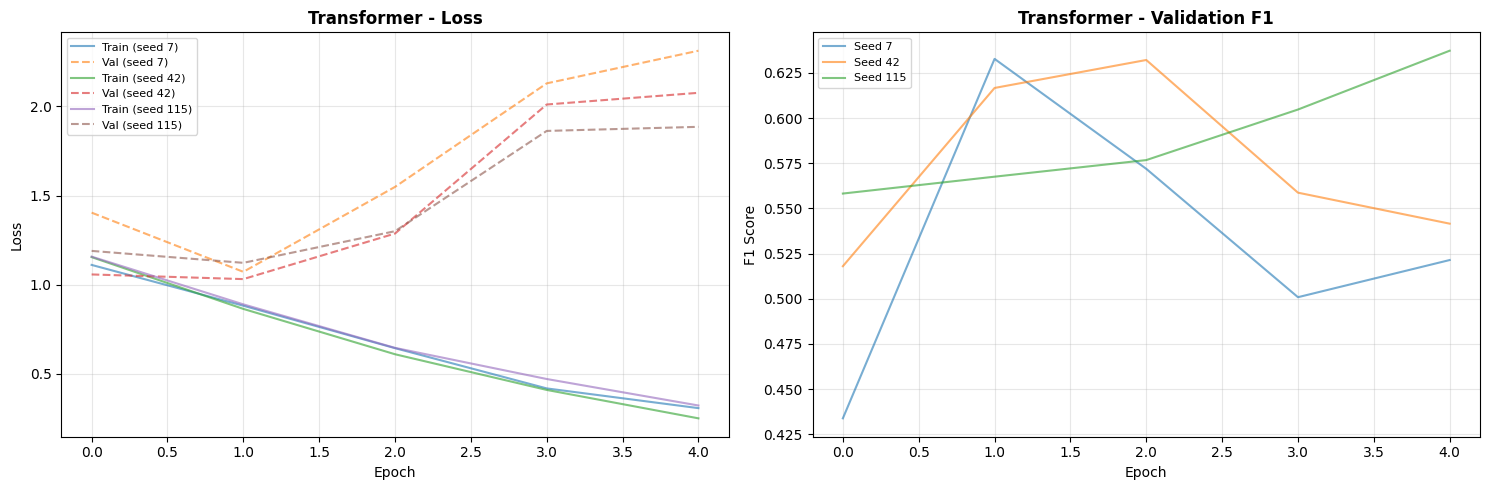

In [101]:
plot_training_curves(transformer_results, title = "Transformer")

The loss plot shows the same train/validation divergence seen in
the BiLSTM models, but this is again expected since the best
checkpoint is selected based on validation F1 rather than loss.

The F1 plot shows that all three seeds start from a higher baseline (~ 0.43-0.56) compared to the BiLSTMs,
confirming the advantage of starting from pre-trained representations.
However, the seeds show different trajectories: seed 7 peaks at
epoch 1 and then drops, seed 42 peaks at epoch 2 and slowly
decreases, while seed 115 improves steadily throughout training.
This suggests that with only 5 epochs, the model has not fully
converged and training for more epochs could potentially improve
performance further, at the risk of overfitting.
Overall, all seeds reach a strong F1 range (~0.50-0.62), well
above what either BiLSTM model achieves.

Compute and display mean ± std results over seeds for the transformer model on both validation and test sets:

In [102]:
models_list = ["transformer"]
model_stats = {
    "transformer": compute_statistics(transformer_results)
}

val_df = build_results_df(model_stats, "validation", models_list)
test_df = build_results_df(model_stats, "test", models_list)

print("\nVALIDATION SET RESULTS (Mean \u00b1 Std over seeds)")
display(val_df)

print("\n\nTEST SET RESULTS (Mean \u00b1 Std over seeds)")
display(test_df)


VALIDATION SET RESULTS (Mean ± Std over seeds)


,Model,F1 (macro),Precision,Recall
0,transformer,0.6340 ± 0.0023,0.6719 ± 0.0310,0.6249 ± 0.0191




TEST SET RESULTS (Mean ± Std over seeds)


,Model,F1 (macro),Precision,Recall
0,transformer,0.4945 ± 0.0126,0.5166 ± 0.0193,0.5040 ± 0.0103


The transformer achieves a much higher validation macro F1 (0.6340)
compared to both BiLSTM models, with an extremely low standard
deviation (±0.0023), meaning the results are almost identical
across all three seeds. This confirms that fine-tuning a pre-trained
model is significantly more stable and effective than training an
LSTM from scratch.

The most notable observation is the large drop between validation
and test set (0.6340 vs 0.4945). This gap is larger than what we
saw for the BiLSTM models and suggests that the transformer is
overfitting to the validation set. Nevertheless, the test F1 of
0.4945 still comfortably outperforms both BiLSTM models, confirming
the transformer as the best overall model.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

As expected, the transformer achieves the highest macro F1 on both
validation (0.6340) and test (0.4945) sets, followed by the stacked
BiLSTM (0.3872 / 0.3617) and the baseline (0.3566 / 0.3508).
The transformer's advantage is clear and consistent across all
metrics (F1, precision, recall), confirming that pre-trained contextual
representations provide a large improvement over recurrent models
trained from scratch.

Between the two BiLSTM variants, the stacked model outperforms the
baseline, but only by a small margin on both validation and test.
This suggests that adding a second BiLSTM layer brings limited
benefit for this task.

#### Confusion matrices

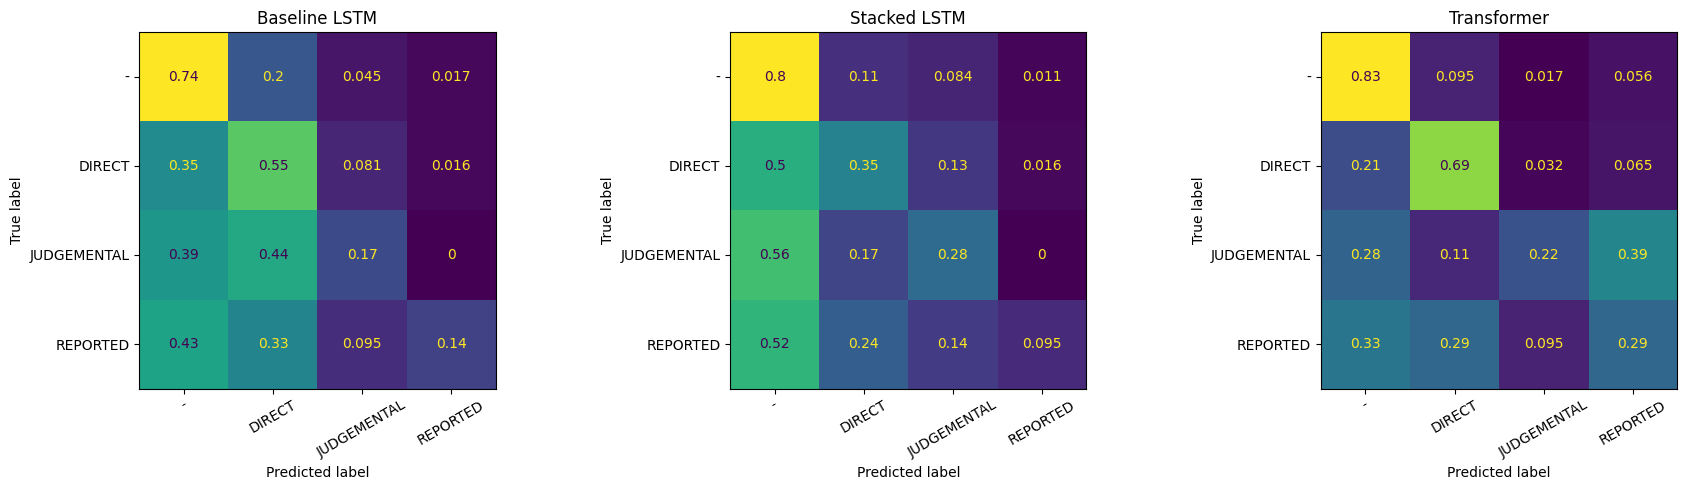

In [103]:
LABELS = sorted(label_map, key=label_map.get) # This will give ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']

def majority_vote(preds_list):
    # preds_list: list of 3 arrays, shape (N,)
    # Ensure predictions are integers before passing to mode
    stacked = np.stack(preds_list, axis=1).astype(int)  # (N, 3)
    # scipy.stats.mode returns (mode_values, counts). We need only mode_values
    voted, _ = scipy.stats.mode(stacked, axis=1, keepdims=True)
    return voted.flatten()

# Extract true labels (they are the same for all models/seeds on the test set)
y_true = baseline_results['test_metrics'][0]['labels']

# Extract predictions for each model and seed
baseline_preds_list = [res['predictions'] for res in baseline_results['test_metrics']]
stacked_preds_list = [res['predictions'] for res in stacked_results['test_metrics']]
transformer_preds_list = [res['predictions'] for res in transformer_results['test_metrics']]

# Apply majority voting
models = {
    "Baseline LSTM":  majority_vote(baseline_preds_list),
    "Stacked LSTM":   majority_vote(stacked_preds_list),
    "Transformer":    majority_vote(transformer_preds_list),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, preds, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=30)
    ax.set_title(name)
plt.tight_layout()
plt.show()

All three models perform best on the non-sexist class ('-'), which
is expected given its dominance in the dataset. The transformer
achieves the highest recall on this class (0.83), but interestingly
the stacked model is also competitive (0.80).

For the DIRECT class, the transformer is clearly the strongest
(0.69), while the baseline (0.55) and especially the stacked model
(0.35) struggle more, with a large fraction of DIRECT tweets being
misclassified as non-sexist.

JUDGEMENTAL remains the hardest class for all models. Both LSTMs
mostly predict non-sexist (0.39 and 0.56 respectively), while the
transformer distributes errors more evenly but frequently confuses
JUDGEMENTAL with REPORTED (0.39).

For the REPORTED class, all models struggle similarly, with most
errors going towards non-sexist or DIRECT. The transformer shows
a slightly better balance, spreading predictions more evenly
across classes rather than collapsing into non-sexist.

Overall, the transformer is the strongest model across all sexist
categories, but all three models share a tendency to over-predict the non-sexist class at the expense of the minority categories.

#### Precision/Recall curves

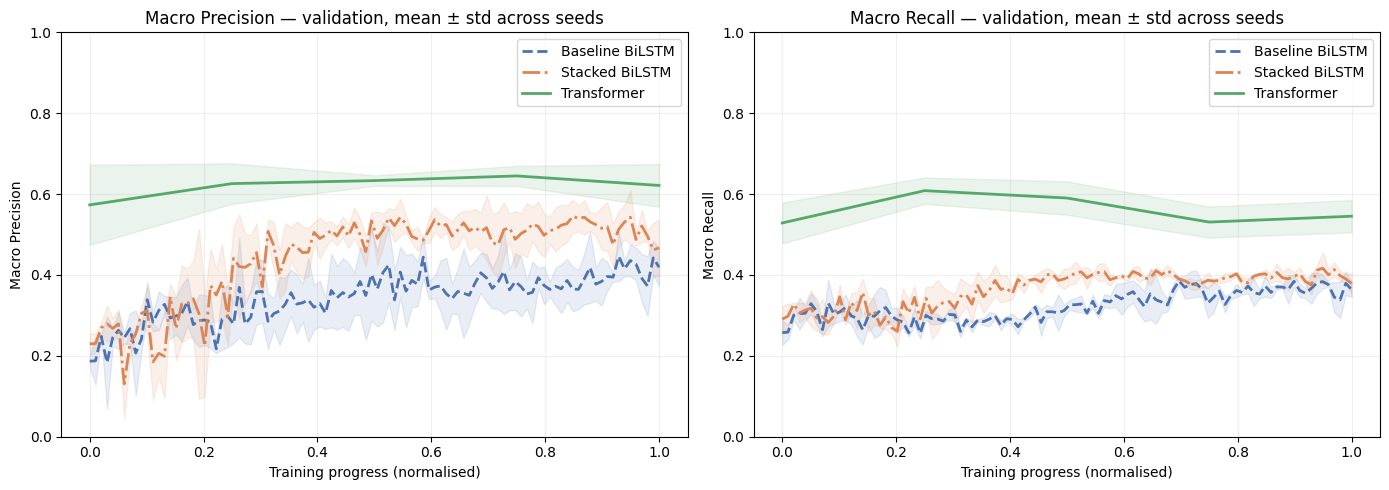

In [104]:
def plot_pr_curves(results_dict):
    """
    results_dict: {
        "Baseline BiLSTM":  baseline_results,   # history in test_metrics[i]['history']
        "Stacked BiLSTM":   stacked_results,    # history in test_metrics[i]['history']
        "Transformer":      transformer_results  # history in histories[i]
    }
    """
    colors  = {
        "Baseline BiLSTM": "#4C72B0",
        "Stacked BiLSTM":  "#DD8452",
        "Transformer":     "#55A868"
    }
    linestyles = {
        "Baseline BiLSTM": "--",
        "Stacked BiLSTM":  "-.",
        "Transformer":     "-"
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for model_name, results in results_dict.items():
        color = colors[model_name]
        ls    = linestyles[model_name]

        # ── unified history extraction ───────────────────────────────────────
        if 'histories' in results and isinstance(results['histories'][0], dict):
            # Transformer: histories stored at top level
            histories = results['histories']
        else:
            # LSTM: histories stored inside test_metrics
            histories = [r['history'] for r in results['test_metrics']]

        all_p = np.array([h['val_precision'] for h in histories])  # (n_seeds, n_epochs)
        all_r = np.array([h['val_recall']    for h in histories])

        mean_p, std_p = all_p.mean(axis=0), all_p.std(axis=0)
        mean_r, std_r = all_r.mean(axis=0), all_r.std(axis=0)

        # normalise x-axis to [0, 1] so models with different epoch counts are comparable
        n_epochs  = all_p.shape[1]
        x = np.linspace(0, 1, n_epochs)

        for ax, mean, std, metric in zip(
            axes,
            [mean_p, mean_r],
            [std_p,  std_r],
            ["Macro Precision", "Macro Recall"]
        ):
            ax.plot(x, mean, label=model_name, color=color, linestyle=ls, linewidth=2)
            ax.fill_between(x, mean - std, mean + std, alpha=0.12, color=color)

    for ax, metric in zip(axes, ["Macro Precision", "Macro Recall"]):
        ax.set_xlabel("Training progress (normalised)")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} — validation, mean ± std across seeds")
        ax.legend()
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig("pr_curves.png", dpi=150)
    plt.show()

# usage
plot_pr_curves({
    "Baseline BiLSTM": baseline_results,
    "Stacked BiLSTM":  stacked_results,
    "Transformer":     transformer_results,
})

The PR curves reveal fundamentally different learning dynamics between the two architecture families.

The transformer starts from a significantly higher baseline (~0.58 precision, ~0.53 recall) and remains stable throughout training, ending at ~0.62 precision and ~0.54 recall. This smooth trajectory, combined with a narrow ± std band, reflects the stability of fine-tuning a pre-trained encoder: the model begins with rich contextual representations and progressively adapts them to the task.

Both BiLSTM variants start much lower (~ 0.20-0.25 precision, ~ 0.28-0.30 recall) and improve gradually in the first 40% of training before stabilizing. The stacked model consistently outperforms the baseline on precision (~ 0.50-0.55 vs ~ 0.40-0.45), while on recall the two models are more similar (~ 0.38-0.42). The wider shaded band of the baseline confirms its higher sensitivity to random initialization compared to the stacked model.

#### Specific misclassified samples
We inspect a selection of misclassified examples to identify recurring
error patterns across the three models. This helps understand the
structural limitations of each approach beyond what aggregate metrics reveal.

In [105]:
all_preds = [models["Baseline LSTM"], models["Stacked LSTM"], models["Transformer"]]
# Reshape into a single list of all individual seed predictions to check for 'wrong_mask'
# This part assumes you want to check if *any* model/seed got it wrong.
# However, the previous intention seemed to be checking if *all* models (after majority vote) got it wrong.
# Reverting to the original logic that checks if the overall majority vote prediction of each model is wrong

wrong_mask = np.ones(len(y_true), dtype=bool)
for model_name, preds_array in models.items():
    wrong_mask &= (preds_array != y_true)

hard_indices = np.where(wrong_mask)[0]
print(f"Hard errors: {len(hard_indices)} / {len(y_true)}")

hard_df = pd.DataFrame({
    "text":       [test_df_en['original_tweet'].values[i] for i in hard_indices],
    "true_label": [LABELS[y_true[i]] for i in hard_indices],
    "baseline_pred":     [LABELS[models["Baseline LSTM"][i]] for i in hard_indices],
    "stacked_pred":      [LABELS[models["Stacked LSTM"][i]] for i in hard_indices],
    "transformer_pred":  [LABELS[models["Transformer"][i]] for i in hard_indices],
})

hard_df.to_csv("hard_errors.csv", index=False)
display(hard_df)

Hard errors: 41 / 280


,text,true_label,baseline_pred,stacked_pred,transformer_pred
0,@LogicalFallac18 @LBC Sex* as in 'gender' hara...,-,JUDGEMENTAL,JUDGEMENTAL,REPORTED
1,@BBCYaldaHakim Kabul: Islamic Emirate of Afgha...,REPORTED,JUDGEMENTAL,-,-
2,Appreciate being included along with @wphillip...,-,REPORTED,REPORTED,REPORTED
3,"""The violent antifeminism of a far-right movem...",REPORTED,-,-,-
4,Isa hot girl summer now pop yall shit https://...,-,DIRECT,DIRECT,DIRECT
5,@BoopBepp @Helloth07860784 @Bronwen85 Yup I ha...,-,REPORTED,JUDGEMENTAL,REPORTED
6,Calls to clean up Parliament's laddish culture...,REPORTED,-,-,-
7,It is hard to be a woman. You must think like ...,REPORTED,DIRECT,DIRECT,DIRECT
8,@gokunaruto3000 Idk wtf you looking at 😂 one l...,-,DIRECT,DIRECT,DIRECT
9,@MosaicoDaemonic @heyitsnatalie00 @WhatIsAWoma...,DIRECT,JUDGEMENTAL,JUDGEMENTAL,JUDGEMENTAL


##### Reported speech confusion

In [166]:
hard_df['text'].iloc[7]

'It is hard to be a woman. You must think like a man, act like a lady, look like a young girl, and work like a horse.'

In this tweet, the sexist content is reported by someone
else, ie the author is not the one expressing the sexist view. However,
all models focus on the offensive words themselves and ignore the
reporting frame, predicting DIRECT instead of REPORTED. The models learn to associate certain words with
sexism, but cannot tell whether the author is saying something sexist
or just reporting what someone else said.
(true label -> REPORTED, all models -> DIRECT)

In [164]:
hard_df['text'].iloc[40]

'made this top and my mom gave me the “you look like a whore” expression 😂 anyways here’s this shirt i braided myself https://t.co/0j2mMv47wl'

In this tweet, the author is clearly not being sexist (they are laughing about
what their mom said). However, the word 'whore' is enough to trigger
a DIRECT prediction in the transformer, while the two LSTMs miss
the sexist content entirely and predict non-sexist. None of the
models can understand that the offensive word appears inside a
reported reaction rather than being directed at someone.

In [152]:
hard_df["text"].iloc[34]

'@lykachu_ God the comments on this post are all so idiotic I hate Twitter i hate you all“I women don’t know how condoms work neither do you” you act like you’ve never bought the wrong sized pad or tampon“THEYRE TELLING US WHAT TO DO WITG OUR BODIES” no she doesn’t want a baby or STDs'

This is a tweet where the author is angry and defending women; in fact they are quoting sexist comments that other people made ('I
women don't know how condoms work', 'THEYRE TELLING US WHAT TO
DO WITH OUR BODIES') only to criticise them. The sexist content
is inside the quotes, not coming from the author. However, the
models focus on the offensive quotes themselves and either predict
DIRECT or non-sexist, missing that the author is actually on the
women's side. This is actually are among the longest tweets in the error set and it suggests that long and structurally complex tweets remain
challenging for all models because they require understanding the overall
structure of the message rather than individual words.

##### Subtle and Implicit Sexism

In [163]:
hard_df["text"].iloc[36]

'@RealKidPoker 2. Poker rooms. The other fallacy I think you have is in terms of your comparison to romance novels; while you may be correct that there may be a difference in interest, in your comparison there are no barriers for men to buy romance novels. Women have to brace themselves for'

This tweet makes a judgemental observation
about gender inequality in poker rooms but it does not contain any explicit slurs or aggressive
language. Since there are no
obvious cues, two out of three models classify it as
non-sexist. Detecting this kind of implicit sexism would require
understanding context and intent, which is beyond what these models
currently do.

In [156]:
hard_df["text"].iloc[17]

'Going to sleep soon but Im so furious about what is happening to women’s right to autonomy over in the states now.. Some men where i am complain that feminism has become oppression of men, but i dont think they realize the real fear women live with.. wondering if some day we too'

Here, the author is
expressing genuine concern about women's rights and frustration
towards men who dismiss feminism and so a clearly judgemental stance
about gender dynamics. However, the tweet is written in a calm,
personal and empathetic tone with no offensive language whatsoever.
As a result, both LSTMs predict non-sexist, completely failing to
detect any sexism, while the transformer predicts REPORTED, also
missing the judgemental stance. Detecting this kind of sexism
requires understanding the author's emotional and political position,
which goes beyond what surface word matching can achieve.

##### OOV and rare words

In [162]:
print(embedding_model.key_to_index.get('phallocentrism'))

None


In [161]:
hard_df["text"].iloc[21]

"Fuck's sake is it possible to have a furry space that's not explicitly content-restricted and doesn't immediately become yet another showcase for size-queen phallocentrism?"

In [160]:
hard_df["text"].iloc[22]

'Freud claims girls have a dicklet. The clitoris has phallic significance. Phallocentrism reduces even female genitalia to the Phallus. The other parts of the vagina, the clit, and more constitute the plurality of female sexuality. The clit coexists with non-phallic body parts.'

Both tweets use the rare  term 'phallocentrism', which is
not in the GloVe vocabulary and is therefore treated
as an unknown token by the LSTM models. As expected, both LSTMs
predict non-sexist. The transformer does slightly better on index 22
(predicting DIRECT) because its subword tokenization can break the
word into smaller known pieces instead of treating it as a single
unknown token.

##### Sarcasm and negation

In [158]:
hard_df["text"].iloc[5]

'@BoopBepp @Helloth07860784 @Bronwen85 Yup I hate when men rape and kill women. https://t.co/MyfVPu6THd'

In [157]:
hard_df["text"].iloc[16]

"@ShelleyKingsto3 @CNP_MacFarlane @CanadianinAB It's objectification &amp; dehumanizing. I saw someone take time out of their day to make a strong political point about Horwath 🙄(sarcasm) -- he Tweeted about how her photo looked like it had lots of photoshop. Such pathetic clowns."

In index 5, the author is condemning violence against women ('I
hate when men rape and kill women'), yet the words 'rape' and 'kill' are enough to trigger a sexist
prediction in all models. In index 16, the author explicitly marks
their own sarcasm in the text ('(sarcasm)') and is criticising sexist
behavior, yet all models still miss it. Both cases show the same
problem: the models cannot reverse the meaning of a sentence when the
author's intent is the opposite of what the words literally suggest.
(true label → -, all models misclassify as sexist)

##### Non-sexist misclassified as DIRECT

In [154]:
hard_df["text"].iloc[28]

'I’m just a pretty little freaky black slut who wants to be filled up with cum and treated like a princess 🥰 Look at the view 🥵  scenes from my first scat video :) #nsfwtwt #blonde #babygirl #creamyebony #creamypussy #daddysgirl #horny #ebonyteen #slut #useme #dmme https://t.co/EVIBF3apqp'

The annotators labeled this tweet as non-sexist since the
author is self-describing and so not targeting or demeaning anyone else. However, all three models predict DIRECT,
triggered by the explicit vocabulary. This reflects a core limitation:
models learn to associate certain words with sexism regardless of
who is saying them and in what context.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!